# Generador de animales salvajes con DCGAN condicional

En este cuadernillo construiremos una *DCGAN condicional* capaz de generar imágenes de seis especies del dataset **Wild Life Animals**: guepardo, zorro, hiena, león, tigre y lobo.

La implementación sigue el estilo de `example_GAN.ipynb`: primero preparamos el dataset, luego definimos el generador y el discriminador, escribimos el bucle de entrenamiento y finalmente generamos nuevas imágenes.

## Decisiones para este dataset

El dataset contiene las mismas imágenes en resoluciones de 224, 300 y 512 píxeles. Usaremos solamente las carpetas `*-resize-224` y transformaremos las imágenes a **64 x 64 píxeles** durante la carga. De este modo no repetimos tres veces cada fotografía y el entrenamiento es más accesible.

En lugar de entrenar seis modelos independientes, entrenaremos **un solo modelo condicional**. El generador recibe ruido y la especie deseada, por lo que podremos pedir explícitamente un león, un lobo, etc. Compartir características entre clases también es conveniente porque cada especie dispone de pocas centenas de imágenes.

## Preparación

Importamos las librerías, fijamos una semilla para poder repetir los experimentos y seleccionamos GPU cuando esté disponible.

In [1]:
from pathlib import Path
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from fastprogress import master_bar, progress_bar

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [2]:
dataset_candidates = [
  Path(r"C:\Users\aaran\Downloads\Wildlife Animals Images"),
  Path(r"C:\Users\aaran\Download\Wildlife Animals Images")
]
DATASET_PATH = next((path for path in dataset_candidates if path.exists()), dataset_candidates[0])
assert DATASET_PATH.exists(), f"No se encontró el dataset en {DATASET_PATH}"

classes = ("cheetah", "fox", "hyena", "lion", "tiger", "wolf")
class_to_idx = {name: ix for ix, name in enumerate(classes)}
IMAGE_SIZE = 64
BATCH_SIZE = 32
LATENT_SIZE = 100

OUTPUT_PATH = Path("./GAN/wildlife_dcgan_outputs_v2") if Path("./GAN").exists() else Path("./wildlife_dcgan_outputs_v2")
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
DATASET_PATH, OUTPUT_PATH

(Path('C:/Users/aaran/Downloads/Wildlife Animals Images'),
 Path('wildlife_dcgan_outputs_v2'))

## El dataset

Las imágenes se encuentran dentro de subcarpetas con nombres diferentes según la especie. Para que el código funcione en todos los casos, buscaremos los archivos de imagen de manera recursiva y verificaremos cada archivo antes de construir el dataset. Los archivos vacíos o dañados serán reportados y excluidos automáticamente. También aplicaremos aumentos moderados de datos y normalizaremos los píxeles al rango `[-1, 1]`, que es el rango de salida de `tanh`.

In [3]:
extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
image_paths, image_labels = [], []

for label, name in enumerate(classes):
  class_path = DATASET_PATH / f"{name}-resize-224"
  assert class_path.exists(), f"No se encontró la clase: {class_path}"
  paths = sorted(path for path in class_path.rglob("*") if path.suffix.lower() in extensions)
  image_paths.extend(paths)
  image_labels.extend([label] * len(paths))

valid_paths, valid_labels, invalid_paths = [], [], []
for path, label in zip(image_paths, image_labels):
  try:
    with Image.open(path) as image:
      image.verify()
    valid_paths.append(path)
    valid_labels.append(label)
  except (OSError, SyntaxError):
    invalid_paths.append(path)

image_paths, image_labels = valid_paths, valid_labels
print(f"Imágenes válidas: {len(image_paths)}")
print(f"Imágenes dañadas descartadas: {len(invalid_paths)}")
[str(path) for path in invalid_paths]

Imágenes válidas: 1723
Imágenes dañadas descartadas: 2


['C:\\Users\\aaran\\Downloads\\Wildlife Animals Images\\cheetah-resize-224\\resize-224\\00000244_224resized.png',
 'C:\\Users\\aaran\\Downloads\\Wildlife Animals Images\\hyena-resize-224\\resize-224\\00000224_224resized.png']

In [4]:
class Dataset(torch.utils.data.Dataset):
  def __init__(self, paths, labels):
    self.paths = paths
    self.labels = labels
    self.transform = transforms.Compose([
      transforms.Resize(72),
      transforms.RandomCrop(IMAGE_SIZE),
      transforms.RandomHorizontalFlip(),
      transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
      transforms.ToTensor(),
      transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

  def __len__(self):
    return len(self.paths)

  def __getitem__(self, ix):
    with Image.open(self.paths[ix]) as image:
      image = image.convert("RGB")
      image = self.transform(image)
    return image, self.labels[ix]

train = Dataset(image_paths, image_labels)
len(train)

1723

In [5]:
counts = pd.Series(image_labels).value_counts().sort_index()
dataset_summary = pd.DataFrame({
  "class": classes,
  "images": [counts.get(ix, 0) for ix in range(len(classes))]
})
dataset_summary

,class,images
0,cheetah,342
1,fox,250
2,hyena,305
3,lion,294
4,tiger,269
5,wolf,263


Como las clases no tienen exactamente la misma cantidad de imágenes, utilizaremos un muestreador ponderado. Así, todas las especies aparecerán aproximadamente con la misma frecuencia durante el entrenamiento.

In [6]:
class_weights = 1. / counts
sample_weights = torch.tensor([class_weights[label] for label in image_labels], dtype=torch.double)
sampler = torch.utils.data.WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

dataloader = torch.utils.data.DataLoader(
  train,
  batch_size=BATCH_SIZE,
  sampler=sampler,
  drop_last=True,
  num_workers=0,
  pin_memory=device == "cuda"
)

imgs, labels = next(iter(dataloader))
imgs.shape, labels.shape, imgs.max(), imgs.min()

(torch.Size([32, 3, 64, 64]), torch.Size([32]), tensor(1.), tensor(-1.))

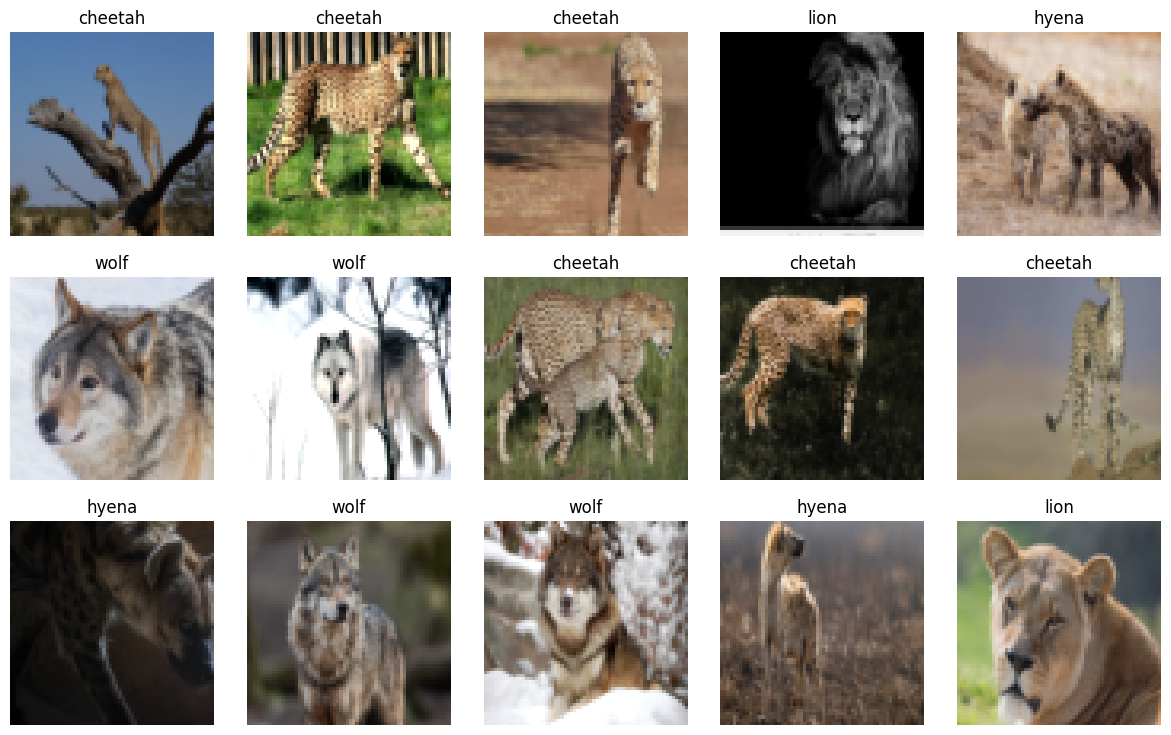

In [7]:
r, c = 3, 5
plt.figure(figsize=(c*3, r*3))
for row in range(r):
  for col in range(c):
    index = c*row + col
    plt.subplot(r, c, index + 1)
    img = imgs[index] * 0.5 + 0.5
    plt.imshow(img.permute(1, 2, 0))
    plt.axis("off")
    plt.title(classes[labels[index].item()])
plt.subplots_adjust(wspace=0.1, hspace=0.2)
plt.show()

## DCGAN condicional

El generador recibirá un vector de 100 valores aleatorios y una etiqueta de especie. La etiqueta se convierte en un *embedding* y se concatena con el ruido. Después, varias convoluciones transpuestas aumentan la resolución desde 4 x 4 hasta 64 x 64.

In [8]:
class Generator(nn.Module):
  def __init__(self, num_classes=len(classes)):
    super().__init__()
    self.input_size = LATENT_SIZE
    self.num_classes = num_classes
    self.label_embedding = nn.Embedding(num_classes, 50)
    self.inp = nn.Sequential(
      nn.Linear(self.input_size + 50, 512*4*4),
      nn.BatchNorm1d(512*4*4),
      nn.ReLU(True)
    )
    self.main = nn.Sequential(
      nn.ConvTranspose2d(512, 256, 4, stride=2, padding=1, bias=False),
      nn.BatchNorm2d(256),
      nn.ReLU(True),
      nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1, bias=False),
      nn.BatchNorm2d(128),
      nn.ReLU(True),
      nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1, bias=False),
      nn.BatchNorm2d(64),
      nn.ReLU(True),
      nn.ConvTranspose2d(64, 3, 4, stride=2, padding=1, bias=False),
      nn.Tanh()
    )

  def forward(self, noise, labels):
    labels = self.label_embedding(labels)
    x = torch.cat([noise, labels], dim=1)
    x = self.inp(x)
    x = x.view(-1, 512, 4, 4)
    x = self.main(x)
    return x

El discriminador también recibe la especie. Su *embedding* se transforma en un canal adicional de 64 x 64 y se concatena con la imagen RGB. Usaremos activaciones `LeakyReLU` y `Dropout2d` para reducir el sobreajuste del discriminador, algo importante en un dataset pequeño. La salida son *logits*, por lo que durante el entrenamiento usaremos `BCEWithLogitsLoss`.

In [9]:
class Discriminator(nn.Module):
  def __init__(self, num_classes=len(classes)):
    super().__init__()
    self.label_embedding = nn.Embedding(num_classes, IMAGE_SIZE*IMAGE_SIZE)
    self.main = nn.Sequential(
      nn.Conv2d(4, 32, 4, stride=2, padding=1, bias=False),
      nn.LeakyReLU(0.2, inplace=True),
      nn.Dropout2d(0.2),
      nn.Conv2d(32, 64, 4, stride=2, padding=1, bias=False),
      nn.InstanceNorm2d(64, affine=True),
      nn.LeakyReLU(0.2, inplace=True),
      nn.Dropout2d(0.2),
      nn.Conv2d(64, 128, 4, stride=2, padding=1, bias=False),
      nn.InstanceNorm2d(128, affine=True),
      nn.LeakyReLU(0.2, inplace=True),
      nn.Dropout2d(0.2),
      nn.Conv2d(128, 256, 4, stride=2, padding=1, bias=False),
      nn.InstanceNorm2d(256, affine=True),
      nn.LeakyReLU(0.2, inplace=True),
      nn.Dropout2d(0.2),
      nn.Conv2d(256, 1, 4, stride=1, padding=0, bias=False)
    )

  def forward(self, x, labels):
    labels = torch.tanh(self.label_embedding(labels)).view(-1, 1, IMAGE_SIZE, IMAGE_SIZE)
    x = torch.cat([x, labels], dim=1)
    x = self.main(x)
    return x.view(-1, 1)

Inicializamos las convoluciones con la distribución recomendada para DCGAN: media 0 y desviación estándar 0.02.

In [10]:
def weights_init(module):
  classname = module.__class__.__name__
  if "Conv" in classname or "Linear" in classname:
    nn.init.normal_(module.weight.data, 0.0, 0.02)
    if getattr(module, "bias", None) is not None:
      nn.init.constant_(module.bias.data, 0)
  elif "Norm" in classname:
    nn.init.normal_(module.weight.data, 1.0, 0.02)
    nn.init.constant_(module.bias.data, 0)

generator = Generator().apply(weights_init)
discriminator = Discriminator().apply(weights_init)

noise = torch.randn(8, generator.input_size)
test_labels = torch.arange(8) % len(classes)
generated_images = generator(noise, test_labels)
output = discriminator(generated_images, test_labels)
generated_images.shape, output.shape

(torch.Size([8, 3, 64, 64]), torch.Size([8, 1]))

## El entrenamiento

Entrenaremos ambas redes por turnos, como en el cuadernillo de ejemplo. Mantendremos ambas redes en modo `train()` durante los dos pasos para que el discriminador se comporte de manera consistente. También añadiremos *label smoothing*, ruido de instancia decreciente, limitación de gradientes y dos actualizaciones del generador por cada actualización del discriminador.

No seleccionaremos el modelo por el menor `g_loss`: en una GAN una pérdida pequeña no significa necesariamente una mejor imagen. Usaremos un promedio exponencial de los pesos del generador (EMA), checkpoints visuales y una parada temprana que solamente actúa si el discriminador domina persistentemente después del calentamiento. Los resultados nuevos se guardarán en `wildlife_dcgan_outputs_v2`.

In [11]:
class EarlyStopping:
  def __init__(self, patience=40, warmup=80):
    self.patience = patience
    self.warmup = warmup
    self.counter = 0

  def step(self, d_real, d_fake, epoch):
    if epoch < self.warmup:
      self.counter = 0
      return False
    discriminator_dominates = d_real > 0.90 and d_fake < 0.02
    if discriminator_dominates:
      self.counter += 1
    else:
      self.counter = 0
    return self.counter >= self.patience

In [12]:
def set_requires_grad(model, value):
  for parameter in model.parameters():
    parameter.requires_grad_(value)

@torch.no_grad()
def update_ema(ema, model, decay=0.995):
  ema_parameters = dict(ema.named_parameters())
  model_parameters = dict(model.named_parameters())
  for name, parameter in model_parameters.items():
    ema_parameters[name].mul_(decay).add_(parameter, alpha=1. - decay)
  for ema_buffer, model_buffer in zip(ema.buffers(), model.buffers()):
    ema_buffer.copy_(model_buffer)

def save_samples(g, noise, labels, epoch):
  g.eval()
  with torch.no_grad():
    images = g(noise, labels).cpu()
  torchvision.utils.save_image(
    images, OUTPUT_PATH / f"epoch_{epoch:03d}.png",
    nrow=8, normalize=True, value_range=(-1, 1)
  )

def save_checkpoint(g, epoch):
  torch.save({
    "generator": g.state_dict(),
    "classes": classes,
    "latent_size": g.input_size,
    "image_size": IMAGE_SIZE,
    "epoch": epoch
  }, OUTPUT_PATH / f"generator_epoch_{epoch:03d}.pt")

def fit(g, d, dataloader, epochs=200):
  g.to(device)
  d.to(device)
  ema_g = copy.deepcopy(g).to(device).eval()
  set_requires_grad(ema_g, False)
  g_optimizer = torch.optim.Adam(g.parameters(), lr=2e-4, betas=(0.5, 0.999))
  d_optimizer = torch.optim.Adam(d.parameters(), lr=1e-4, betas=(0.5, 0.999))
  crit = nn.BCEWithLogitsLoss()
  early_stopping = EarlyStopping(patience=40, warmup=80)
  hist = {"g_loss": [], "d_loss": [], "d_real": [], "d_fake": [], "g_fool": []}

  samples_per_class = 8
  fixed_noise = torch.randn(len(classes)*samples_per_class, g.input_size, device=device)
  fixed_labels = torch.arange(len(classes), device=device).repeat_interleave(samples_per_class)
  mb = master_bar(range(1, epochs+1))

  for epoch in mb:
    g.train()
    d.train()
    g_loss, d_loss, d_real, d_fake, g_fool = [], [], [], [], []
    instance_noise = max(0., 0.1 * (1. - (epoch - 1) / 100.))

    for X, y in progress_bar(dataloader, parent=mb):
      X = X.to(device, non_blocking=True)
      y = y.to(device, non_blocking=True)
      batch_size = X.size(0)

      # entrenamos el discriminador
      set_requires_grad(d, True)
      noise = torch.randn(batch_size, g.input_size, device=device)
      fake_labels = torch.randint(0, len(classes), (batch_size,), device=device)
      with torch.no_grad():
        generated_images = g(noise, fake_labels)
      real_images = (X + instance_noise * torch.randn_like(X)).clamp(-1., 1.)
      fake_images = (generated_images + instance_noise * torch.randn_like(generated_images)).clamp(-1., 1.)
      real_gt = torch.empty(batch_size, 1, device=device).uniform_(0.85, 1.0)
      fake_gt = torch.empty(batch_size, 1, device=device).uniform_(0.0, 0.15)

      d_optimizer.zero_grad(set_to_none=True)
      real_output = d(real_images, y)
      fake_output = d(fake_images, fake_labels)
      d_l = 0.5 * (crit(real_output, real_gt) + crit(fake_output, fake_gt))
      d_l.backward()
      nn.utils.clip_grad_norm_(d.parameters(), 5.0)
      d_optimizer.step()

      # entrenamos el generador dos veces para equilibrar el juego
      set_requires_grad(d, False)
      for _ in range(2):
        noise = torch.randn(batch_size, g.input_size, device=device)
        generated_labels = torch.randint(0, len(classes), (batch_size,), device=device)
        generated_images = g(noise, generated_labels)
        generated_images = (generated_images + instance_noise * torch.randn_like(generated_images)).clamp(-1., 1.)
        g_gt = torch.ones(batch_size, 1, device=device)

        g_optimizer.zero_grad(set_to_none=True)
        g_output = d(generated_images, generated_labels)
        g_l = crit(g_output, g_gt)
        g_l.backward()
        nn.utils.clip_grad_norm_(g.parameters(), 5.0)
        g_optimizer.step()
        update_ema(ema_g, g)
        g_loss.append(g_l.item())
        g_fool.append(torch.sigmoid(g_output).mean().item())

      d_loss.append(d_l.item())
      d_real.append(torch.sigmoid(real_output).mean().item())
      d_fake.append(torch.sigmoid(fake_output).mean().item())
      mb.child.comment = f"g_loss {np.mean(g_loss):.4f} d_loss {np.mean(d_loss):.4f}"

    set_requires_grad(d, True)
    epoch_values = [np.mean(values) for values in (g_loss, d_loss, d_real, d_fake, g_fool)]
    for key, value in zip(hist, epoch_values):
      hist[key].append(value)

    mb.write(
      f"Epoch {epoch}/{epochs} g_loss {epoch_values[0]:.4f} "
      f"d_loss {epoch_values[1]:.4f} D(x) {epoch_values[2]:.4f} "
      f"D(G(z)) {epoch_values[3]:.4f} G_fool {epoch_values[4]:.4f}"
    )
    if epoch == 1 or epoch % 5 == 0:
      save_samples(ema_g, fixed_noise, fixed_labels, epoch)
    if epoch % 25 == 0:
      save_checkpoint(ema_g, epoch)

    if early_stopping.step(epoch_values[2], epoch_values[3], epoch):
      mb.write(f"Early stopping por dominio persistente del discriminador en la época {epoch}")
      break

  g.load_state_dict(ema_g.state_dict())
  torch.save({
    "generator": g.state_dict(),
    "classes": classes,
    "latent_size": g.input_size,
    "image_size": IMAGE_SIZE
  }, OUTPUT_PATH / "generator_wildlife.pt")
  return hist

El entrenamiento puede tardar bastante porque ahora realizamos dos pasos del generador por lote. Para obtener resultados útiles se recomiendan entre 100 y 200 épocas con GPU. Los mosaicos EMA se guardan cada cinco épocas y los pesos se guardan cada 25 épocas; así podemos recuperar visualmente un estado anterior si aparece colapso de modo.

In [13]:
EPOCHS = 200
hist = fit(generator, discriminator, dataloader, epochs=EPOCHS)

<div><p>Epoch 1/200 g_loss 0.3983 d_loss 1.5968 D(x) 0.2473 D(G(z)) 0.7731 G_fool 0.6988</p><p>Epoch 2/200 g_loss 0.5731 d_loss 1.3326 D(x) 0.2995 D(G(z)) 0.7138 G_fool 0.5924</p><p>Epoch 3/200 g_loss 0.6666 d_loss 1.0781 D(x) 0.3668 D(G(z)) 0.6415 G_fool 0.5406</p><p>Epoch 4/200 g_loss 0.7008 d_loss 0.9605 D(x) 0.4039 D(G(z)) 0.6042 G_fool 0.5182</p><p>Epoch 5/200 g_loss 0.7079 d_loss 0.9110 D(x) 0.4197 D(G(z)) 0.5873 G_fool 0.5130</p><p>Epoch 6/200 g_loss 0.7256 d_loss 0.8642 D(x) 0.4344 D(G(z)) 0.5648 G_fool 0.5022</p><p>Epoch 7/200 g_loss 0.7379 d_loss 0.8470 D(x) 0.4451 D(G(z)) 0.5606 G_fool 0.4961</p><p>Epoch 8/200 g_loss 0.7236 d_loss 0.8328 D(x) 0.4497 D(G(z)) 0.5557 G_fool 0.5020</p><p>Epoch 9/200 g_loss 0.7065 d_loss 0.8137 D(x) 0.4503 D(G(z)) 0.5424 G_fool 0.5081</p><p>Epoch 10/200 g_loss 0.7339 d_loss 0.8021 D(x) 0.4646 D(G(z)) 0.5421 G_fool 0.4952</p><p>Epoch 11/200 g_loss 0.7346 d_loss 0.7955 D(x) 0.4681 D(G(z)) 0.5412 G_fool 0.4950</p><p>Epoch 12/200 g_loss 0.7485 d_loss 0.7911 D(x) 0.4618 D(G(z)) 0.5340 G_fool 0.4873</p><p>Epoch 13/200 g_loss 0.7358 d_loss 0.7854 D(x) 0.4702 D(G(z)) 0.5348 G_fool 0.4928</p><p>Epoch 14/200 g_loss 0.7121 d_loss 0.8053 D(x) 0.4493 D(G(z)) 0.5415 G_fool 0.5022</p><p>Epoch 15/200 g_loss 0.7510 d_loss 0.7807 D(x) 0.4713 D(G(z)) 0.5304 G_fool 0.4879</p><p>Epoch 16/200 g_loss 0.7265 d_loss 0.7804 D(x) 0.4717 D(G(z)) 0.5346 G_fool 0.4963</p><p>Epoch 17/200 g_loss 0.7427 d_loss 0.7711 D(x) 0.4718 D(G(z)) 0.5247 G_fool 0.4899</p><p>Epoch 18/200 g_loss 0.7275 d_loss 0.7710 D(x) 0.4749 D(G(z)) 0.5312 G_fool 0.4952</p><p>Epoch 19/200 g_loss 0.7503 d_loss 0.7688 D(x) 0.4712 D(G(z)) 0.5270 G_fool 0.4834</p><p>Epoch 20/200 g_loss 0.7018 d_loss 0.7816 D(x) 0.4637 D(G(z)) 0.5368 G_fool 0.5064</p><p>Epoch 21/200 g_loss 0.6959 d_loss 0.7648 D(x) 0.4729 D(G(z)) 0.5282 G_fool 0.5098</p><p>Epoch 22/200 g_loss 0.7245 d_loss 0.7718 D(x) 0.4703 D(G(z)) 0.5301 G_fool 0.4953</p><p>Epoch 23/200 g_loss 0.7338 d_loss 0.7596 D(x) 0.4815 D(G(z)) 0.5254 G_fool 0.4927</p><p>Epoch 24/200 g_loss 0.7147 d_loss 0.7495 D(x) 0.4789 D(G(z)) 0.5218 G_fool 0.4975</p><p>Epoch 25/200 g_loss 0.7202 d_loss 0.7577 D(x) 0.4741 D(G(z)) 0.5235 G_fool 0.4966</p><p>Epoch 26/200 g_loss 0.7015 d_loss 0.7586 D(x) 0.4728 D(G(z)) 0.5260 G_fool 0.5035</p><p>Epoch 27/200 g_loss 0.7274 d_loss 0.7482 D(x) 0.4803 D(G(z)) 0.5183 G_fool 0.4929</p><p>Epoch 28/200 g_loss 0.7281 d_loss 0.7429 D(x) 0.4841 D(G(z)) 0.5176 G_fool 0.4925</p><p>Epoch 29/200 g_loss 0.7159 d_loss 0.7587 D(x) 0.4787 D(G(z)) 0.5293 G_fool 0.4980</p><p>Epoch 30/200 g_loss 0.7121 d_loss 0.7554 D(x) 0.4749 D(G(z)) 0.5243 G_fool 0.4990</p><p>Epoch 31/200 g_loss 0.7205 d_loss 0.7549 D(x) 0.4783 D(G(z)) 0.5258 G_fool 0.4950</p><p>Epoch 32/200 g_loss 0.7304 d_loss 0.7447 D(x) 0.4821 D(G(z)) 0.5194 G_fool 0.4905</p><p>Epoch 33/200 g_loss 0.7253 d_loss 0.7512 D(x) 0.4780 D(G(z)) 0.5225 G_fool 0.4924</p><p>Epoch 34/200 g_loss 0.7319 d_loss 0.7456 D(x) 0.4805 D(G(z)) 0.5189 G_fool 0.4893</p><p>Epoch 35/200 g_loss 0.7187 d_loss 0.7516 D(x) 0.4784 D(G(z)) 0.5238 G_fool 0.4959</p><p>Epoch 36/200 g_loss 0.7201 d_loss 0.7469 D(x) 0.4815 D(G(z)) 0.5234 G_fool 0.4943</p><p>Epoch 37/200 g_loss 0.7350 d_loss 0.7428 D(x) 0.4805 D(G(z)) 0.5162 G_fool 0.4888</p><p>Epoch 38/200 g_loss 0.7204 d_loss 0.7417 D(x) 0.4850 D(G(z)) 0.5195 G_fool 0.4947</p><p>Epoch 39/200 g_loss 0.7168 d_loss 0.7445 D(x) 0.4821 D(G(z)) 0.5202 G_fool 0.4960</p><p>Epoch 40/200 g_loss 0.7209 d_loss 0.7505 D(x) 0.4790 D(G(z)) 0.5231 G_fool 0.4944</p><p>Epoch 41/200 g_loss 0.7147 d_loss 0.7538 D(x) 0.4748 D(G(z)) 0.5237 G_fool 0.4963</p><p>Epoch 42/200 g_loss 0.7083 d_loss 0.7424 D(x) 0.4764 D(G(z)) 0.5174 G_fool 0.4986</p><p>Epoch 43/200 g_loss 0.7080 d_loss 0.7307 D(x) 0.4868 D(G(z)) 0.5135 G_fool 0.4999</p><p>Epoch 44/200 g_loss 0.7288 d_loss 0.7431 D(x) 0.4834 D(G(z)) 0.5207 G_fool 0.4908</p><p>Epoch 45/200 g_loss 0.7181 d_loss 0.7414 D(x) 0.4822 D(G(z)) 0.5195 G_fool 0.4949</p><p>Epoch 46/200 g_loss 0.7163 d_loss 0.7337 

c:\Users\aaran\torch_env\Lib\site-packages\PIL\Image.py:1034: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


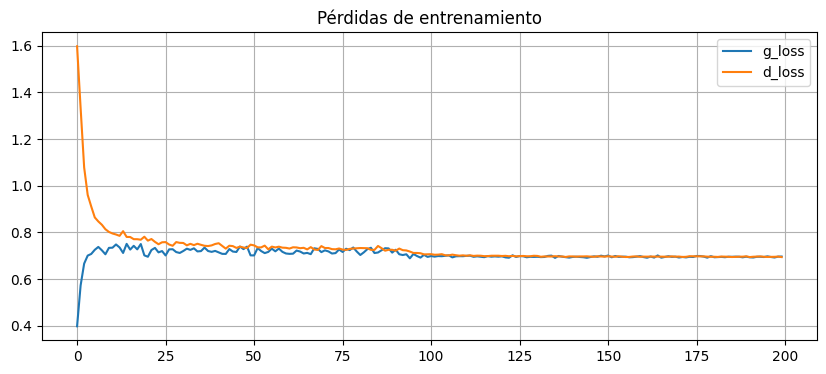

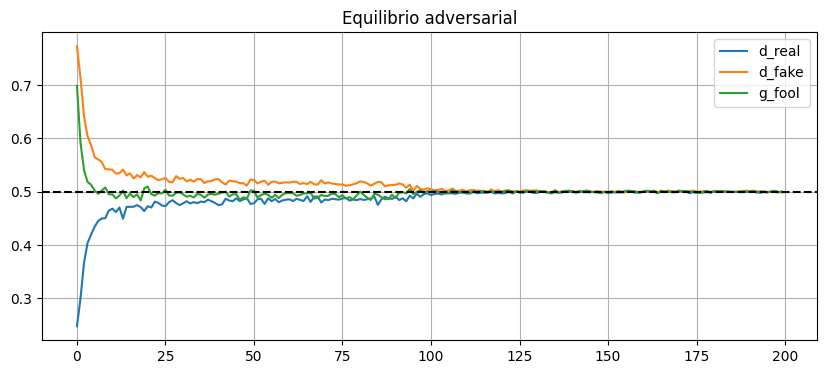

In [14]:
df = pd.DataFrame(hist)
df[["g_loss", "d_loss"]].plot(grid=True, figsize=(10, 4), title="Pérdidas de entrenamiento")
plt.show()

df[["d_real", "d_fake", "g_fool"]].plot(grid=True, figsize=(10, 4), title="Equilibrio adversarial")
plt.axhline(0.5, color="black", linestyle="--")
plt.show()

## Generación de nuevas imágenes

Generaremos ocho ejemplos por especie. Cada fila del mosaico corresponde a una clase en el mismo orden definido al inicio.

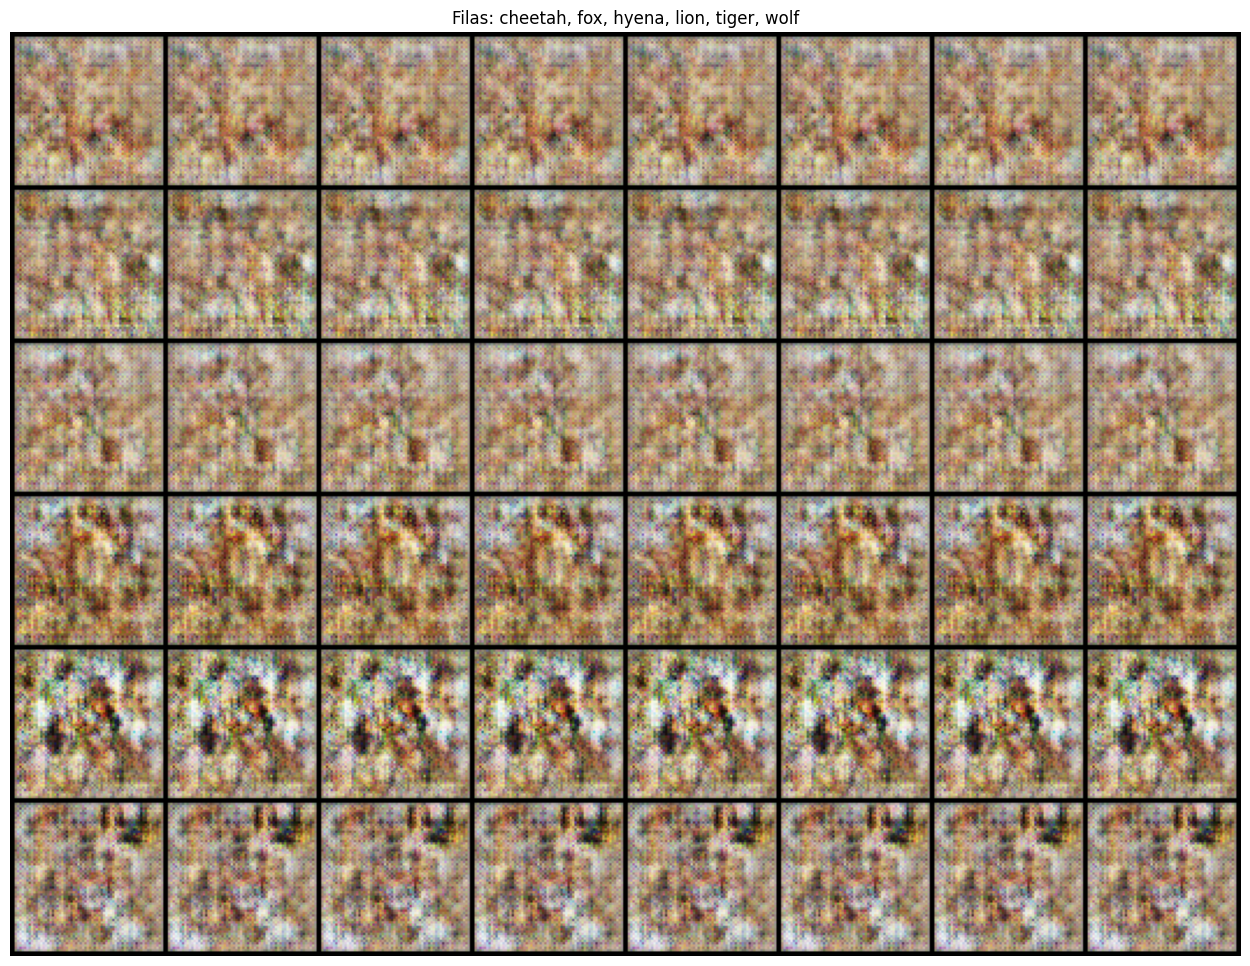

In [15]:
generator.eval()
samples_per_class = 8
with torch.no_grad():
  labels = torch.arange(len(classes), device=device).repeat_interleave(samples_per_class)
  noise = torch.randn(len(labels), generator.input_size, device=device)
  generated_images = generator(noise, labels).cpu()
  grid = torchvision.utils.make_grid(
    generated_images, nrow=samples_per_class, normalize=True, value_range=(-1, 1), padding=2
  )

plt.figure(figsize=(16, 12))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Filas: " + ", ".join(classes))
plt.show()

También podemos pedir una especie concreta utilizando su nombre.

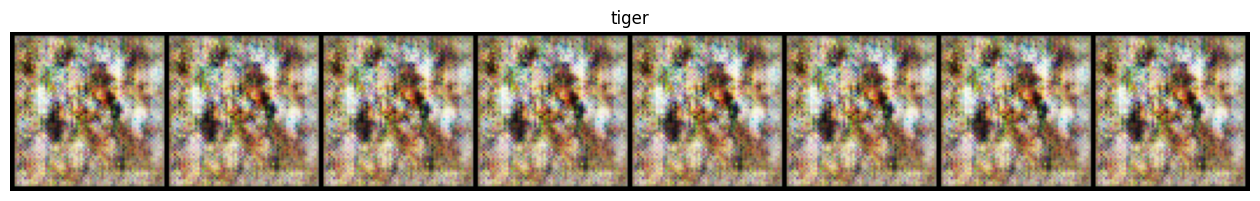

In [16]:
def generate_species(g, species, amount=8):
  assert species in class_to_idx, f"Especie inválida. Opciones: {classes}"
  g.eval()
  label = class_to_idx[species]
  labels = torch.full((amount,), label, dtype=torch.long, device=device)
  noise = torch.randn(amount, g.input_size, device=device)
  with torch.no_grad():
    images = g(noise, labels).cpu()
  grid = torchvision.utils.make_grid(images, nrow=amount, normalize=True, value_range=(-1, 1))
  plt.figure(figsize=(16, 3))
  plt.imshow(grid.permute(1, 2, 0))
  plt.axis("off")
  plt.title(species)
  plt.show()
  return images

images = generate_species(generator, "tiger")

## Cargar el generador entrenado

El archivo `generator_wildlife.pt` contiene los pesos y la configuración mínima necesaria. Esta celda permite reutilizarlo sin volver a entrenar.

In [17]:
checkpoint = torch.load(OUTPUT_PATH / "generator_wildlife.pt", map_location=device)
loaded_generator = Generator(num_classes=len(checkpoint["classes"])).to(device)
loaded_generator.load_state_dict(checkpoint["generator"])
loaded_generator.eval()

Generator(
  (label_embedding): Embedding(6, 50)
  (inp): Sequential(
    (0): Linear(in_features=150, out_features=8192, bias=True)
    (1): BatchNorm1d(8192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (main): Sequential(
    (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(

## Resumen

En este cuadernillo hemos implementado una DCGAN condicional para generar seis especies con un solo modelo. Hemos usado una única copia de cada imagen, muestreo balanceado, aumentos moderados, normalización en `[-1, 1]`, inicialización DCGAN, `Dropout2d`, *label smoothing*, recorte de gradientes, checkpoints visuales y parada temprana.

El dataset es pequeño para generación de imágenes, por lo que la calidad final dependerá de la GPU, el número de épocas y la diversidad real de las fotografías. Si aparece colapso de modo, conviene recuperar un checkpoint visual anterior antes que seleccionar el modelo únicamente por la pérdida.